In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [148]:
# Load dataset
df = pd.read_csv("practo_1000_plus_cleaned.csv")

# Preview
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Doctor_Name          1313 non-null   object 
 1   Hospital_Name        1313 non-null   object 
 2   City                 1313 non-null   object 
 3   Specialization       1313 non-null   object 
 4   Experience_in_years  1313 non-null   int64  
 5   Consultation_Fee     1313 non-null   float64
 6   Patient_Rating       1313 non-null   float64
 7   Reviews              1313 non-null   int64  
 8   Source               1313 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 92.4+ KB


,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews
count,1313.000000,1313.000000,1313.000000,1313.000000
mean,23.492765,876.867080,90.381073,161.268088
std,9.533965,525.967413,12.974849,384.628635
min,2.000000,5.000000,20.000000,1.000000
25%,17.000000,500.000000,90.000000,7.000000
50%,22.000000,800.000000,94.000000,41.000000
75%,28.000000,1000.000000,99.000000,161.000000
max,59.000000,5400.000000,100.000000,5039.000000


In [149]:
df.head()

,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Source
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58,Practo
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777,Practo
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107,Practo
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5,Practo
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251,Practo


In [150]:
df["Source"].nunique()

1

In [151]:
df.drop("Source", axis=1, inplace=True)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Doctor_Name          1313 non-null   object 
 1   Hospital_Name        1313 non-null   object 
 2   City                 1313 non-null   object 
 3   Specialization       1313 non-null   object 
 4   Experience_in_years  1313 non-null   int64  
 5   Consultation_Fee     1313 non-null   float64
 6   Patient_Rating       1313 non-null   float64
 7   Reviews              1313 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 82.2+ KB


- The Source column was removed during preprocessing because it contained only one unique value (‘Practo’) across all records and therefore did not contribute meaningful analytical information.

<h1 align=center> PHASE-01: DISCRIPTIVE MARKET OVERVIEW </h1>

### **POINT OF DISCUSSION & ANALYSIS:**
**1.Overall Fee Landscape**

**2.City-wise Pricing Analysis** 

**3.Specialization-wise Pricing Analysis** 

### 1. Overall Fee Landscape

In [153]:
fee_stats = df["Consultation_Fee"].agg({
    "Average Fee": "mean",
    "Median Fee": "median",
    "Minimum Fee": "min",
    "Maximum Fee": "max",
    "Std Deviation": "std",
    "Total Doctors": "count"
}).round(2)

fee_stats

Average Fee       876.87
Median Fee        800.00
Minimum Fee         5.00
Maximum Fee      5400.00
Std Deviation     525.97
Total Doctors    1313.00
Name: Consultation_Fee, dtype: float64

***A) Creating a histogram to visualize the distribution of consultation fees:***

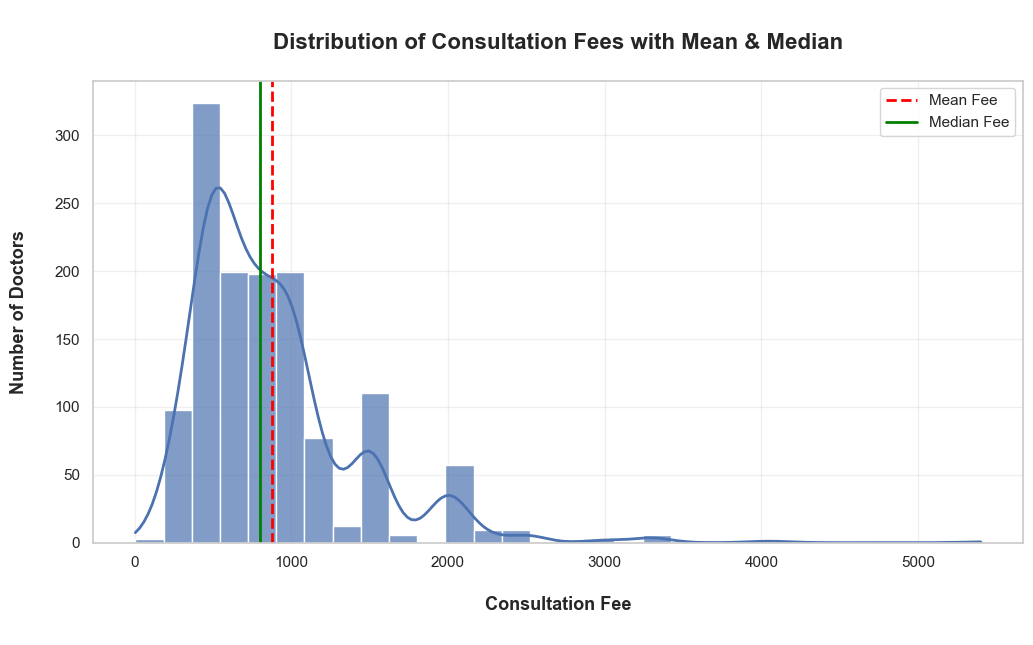

In [154]:
sns.set_theme(style="whitegrid") # "whitegrid" adds a white background with light grid lines
plt.figure(figsize=(12,6))

sns.histplot(
    df["Consultation_Fee"],
    bins=30,
    kde=True, # Enable KDE (Kernel Density Estimation) to show the smooth distribution curve
    color="#4C72B0", # Color of the histogram bars: Dark moderate brown
    alpha=0.7, # Adjust transparency of bars
    line_kws={"linewidth":2, "color":"darkblue"}  # Customize the KDE line
)


# Adding a vertical line showing the mean (average) consultation fee
plt.axvline(
    df["Consultation_Fee"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean Fee'
)


# Adding a vertical line showing the median consultation fee
plt.axvline(
    df["Consultation_Fee"].median(),
    color='green',
    linestyle='-',
    linewidth=2,
    label='Median Fee'
)

plt.title("\nDistribution of Consultation Fees with Mean & Median\n", fontsize=16, fontweight="bold")
plt.xlabel("\nConsultation Fee\n", fontsize=13, fontweight="bold")
plt.ylabel("Number of Doctors\n", fontsize=13, fontweight="bold")

plt.legend() # Display the legend explaining the mean and median lines
plt.grid(alpha=0.3) # Add light grid lines for better readability
plt.show()

### Insights from Consultation Fee Distribution
1. Consultation fees are positively skewed: The mean fee (₹876) is higher than the median fee (₹800), indicating that a small number of doctors charge very high fees.
2. Most doctors charge moderate fees: The majority of consultation fees fall between ₹400 and ₹1000, making this the most common pricing range.
3. Presence of premium-priced doctors: Some doctors charge significantly higher fees (up to ₹1750), suggesting a premium segment in the healthcare market.
4. High variability in consultation fees: The large standard deviation (₹415.59) shows substantial variation in pricing across doctors.
5. The dataset is large and reliable: With data from 1313 doctors, the observed trends and patterns are likely to be meaningful and representative.

***B) Studying the effects of <U>OUTLIERS</U> on Consultancy Fee:***

Our Working Dataframes:
- Raw/Unfiltered/Original Dataset -----------> df
- Filtered Dataset (Without Outliers) -------> df_no_outliers

Average Consultation Fee:
- Original Dataset ---> avg_fee_all
- Filtered Dataset ---> avg_fee_clean

#### IQR METHOD (Outlier Detection):
This method finds extremely low or extremely high consultation fees.

In [11]:
Q1 = df["Consultation_Fee"].quantile(0.25)
Q3 = df["Consultation_Fee"].quantile(0.75)
    
IQR = Q3 - Q1
    
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
    
lower_bound, upper_bound

(np.float64(-250.0), np.float64(1750.0))

In [8]:
df_no_outliers = df[
        (df["Consultation_Fee"] >= lower_bound) &
        (df["Consultation_Fee"] <= upper_bound)
    ]


In [157]:
print(f"Total Number of Doctors in Raw Datasets:- {df.shape[0]}")
print(f"Total Number of Doctors in Filtered Datasets:- {df_no_outliers.shape[0]}") # Filterd Doctors
    
print(f"\nSo, \n  Total Number Of Outliers Found: {df.shape[0] - df_no_outliers.shape[0]}\n")

Total Number of Doctors in Raw Datasets:- 1313
Total Number of Doctors in Filtered Datasets:- 1222

So, 
  Total Number Of Outliers Found: 91



- Average Consultancy fee Comparison `Raw DataSet` vs `Filtered DataSet`:

In [158]:
df_no_outliers.head()

,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251


In [159]:
# Average Consultancy Fee Of Raw DataSet:

avg_fee_all = df["Consultation_Fee"].mean()
print(f"\nAverage Consultancy Fee Of Raw DataSet:- ₹{avg_fee_all:.2f}\n")  # .2f --> Shows decimal upto 2 value


Average Consultancy Fee Of Raw DataSet:- ₹876.87



In [160]:
# Average Consultancy Fee of Filtered DataSet:

avg_fee_clean = df_no_outliers["Consultation_Fee"].mean()
print(f"\nAverage Consultancy Fee of Filtered DataSet:- ₹{avg_fee_clean:.2f}\n")


Average Consultancy Fee of Filtered DataSet:- ₹773.78



In [161]:
# Avg (Mean) Comparison between Raw and Filtered DataSet

comparison = pd.DataFrame({
    "Scenario": ["Raw DataSet (Including Outliers)", "Filtered DataSet (Excluding Outliers)"],
    "Avg_Consultation_Fee": [avg_fee_all, avg_fee_clean]
})

comparison.style.format({"Avg_Consultation_Fee": "₹{:.2f}"})

,Scenario,Avg_Consultation_Fee
0,Raw DataSet (Including Outliers),₹876.87
1,Filtered DataSet (Excluding Outliers),₹773.78


In [162]:
comparison_median = pd.DataFrame({
    "Scenario": ["Raw DataSet (Including Outliers)", "Filtered DataSet (Excluding Outliers)"],
    "Median_Fee_Value": [df["Consultation_Fee"].median(), df_no_outliers["Consultation_Fee"].median()]
})

comparison_median.style.format({"Median_Fee_Value": "₹{:.2f}"})

,Scenario,Median_Fee_Value
0,Raw DataSet (Including Outliers),₹800.00
1,Filtered DataSet (Excluding Outliers),₹700.00


### Visualization using BOX plot
**With Outliers**

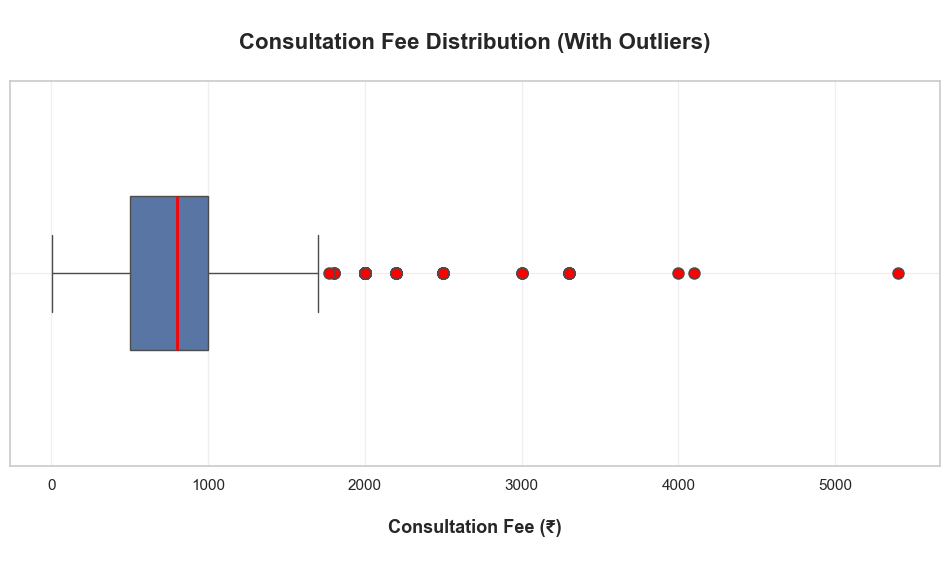

In [163]:
sns.set_theme(style="whitegrid")  # Whitegrid background theme

plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["Consultation_Fee"],
    color="#4C72B0", # color of the box --> Dark moderate blue
    width=0.4, 
    medianprops={"color":"red","linewidth":2}, # Customize the median line inside the box
    flierprops=dict(marker='o', markerfacecolor='red', markersize=8) # Customize the appearance of outliers
)

plt.title("\nConsultation Fee Distribution (With Outliers)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nConsultation Fee (₹)\n", fontsize=13, fontweight="bold")

plt.grid(alpha=0.3) # Added grid lines with light transparency
plt.show()

#### Key Insights:
1. Most doctors charge consultation fees between ₹500–₹1000, representing the common pricing range.
2. Several extreme high-fee outliers (around ₹1800–₹5500) indicate the presence of premium doctors.
3. The distribution is right-skewed, meaning a few very high consultation fees increase the overall average.

In [164]:
# Raw Dataset --> Mean (vs) Median

avg_fee_all = df["Consultation_Fee"].mean()
median_fee_all = df["Consultation_Fee"].median()

print(f"\nMean value (with outlier): {avg_fee_all:.2f}")
print(f"Median value (with outlier):{median_fee_all}\n")
print("So in the first boxplot, the median shows:\n- The typical consultation fee even when extreme values exist.\n")


Mean value (with outlier): 876.87
Median value (with outlier):800.0

So in the first boxplot, the median shows:
- The typical consultation fee even when extreme values exist.



**Without Outliers**

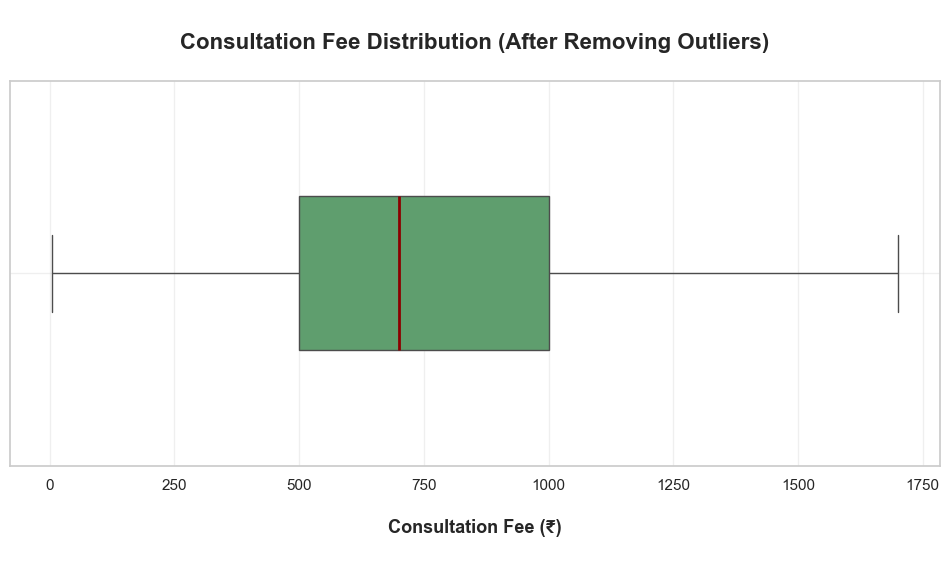

In [165]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,5))


# Create a boxplot for the consultation fees after removing outliers
sns.boxplot(  
    x=df_no_outliers["Consultation_Fee"],  # Used the cleaned dataset where outliers have been removed
    color="#55A868", # Box color --> Greenish
    width=0.4,
    medianprops={"color":"darkred", "linewidth":2}
)

plt.title("\nConsultation Fee Distribution (After Removing Outliers)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nConsultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()


In [166]:
# Filtered Dataset --> Mean (vs) Median

avg_fee_clean = df_no_outliers["Consultation_Fee"].mean()
median_fee_clean = df_no_outliers["Consultation_Fee"].median()

print(f"\nMean value (without outlier): {avg_fee_clean:.2f}")
print(f"Median value (without outlier):{median_fee_clean}\n")
print("Now both mean and median are close, showing a stable distribution.\n")


Mean value (without outlier): 773.78
Median value (without outlier):700.0

Now both mean and median are close, showing a stable distribution.



### Insights:
Now the median represents:
- The middle consultation fee among doctors within the normal fee range.

Because extreme values are removed:
- The distribution becomes tighter
- The box becomes smaller
- The median represents the realistic market fee

### Complete Insights of Fee Landscape

**Insight-01 — Common Consultation Fee Range**
    
    Most doctors charge consultation fees between ₹500 and ₹1000, indicating that this is the dominant pricing range in the healthcare market.

**Insight-02 — Presence of Premium Doctors**
    
    The raw dataset contains extremely high consultation fees reaching up to approximately ₹5500, highlighting the existence of premium or specialized healthcare providers.

**Insight-03 — Effect of Outliers**
    
    After removing outliers using the IQR method, the consultation fee distribution becomes more compact and stable, showing that a small number of high-fee doctors were significantly increasing the overall average.

**Insight-04 — Realistic Market Representation**
    
    The filtered dataset (without outliers) better represents the typical consultation fee range that most patients are likely to encounter in urban healthcare markets.

### **2. CITY-WISE PRICING ANALYSIS:**

**A) Computing Average, Median, Standard Deviation, Min, Max, Doctor Count (Filtered Dataset).**

In [167]:
city_fee_stats = df_no_outliers.groupby("City")["Consultation_Fee"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Std_Deviation="std",
    Min_Fee="min",
    Max_Fee="max",
    Doctors="count"
).round(2)

city_fee_stats.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
City,,,,,,
mumbai,1173.69,1200.0,377.54,500.0,1600.0,112
kolkata,981.33,1000.0,351.08,300.0,1600.0,166
delhi,958.18,1000.0,352.08,300.0,1700.0,55
pune,787.58,800.0,284.49,199.0,1500.0,177
ahmedabad,741.52,700.0,346.09,200.0,1700.0,88
hyderabad,726.36,700.0,216.57,300.0,1500.0,150
chennai,693.04,650.0,237.27,200.0,1400.0,147
lucknow,636.52,600.0,283.17,200.0,1500.0,90
jaipur,533.88,500.0,228.73,5.0,1500.0,178


In [168]:
most_expensive_city = city_fee_stats["Average_Fee"].idxmax()
most_affordable_city = city_fee_stats["Average_Fee"].idxmin()

print(f"\nMost Expensive City: {most_expensive_city}")
print(f"Most Affordable City: {most_affordable_city}\n")


Most Expensive City: mumbai
Most Affordable City: bangalore



C:\Users\suvarna\AppData\Local\Temp\ipykernel_26724\3827771714.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


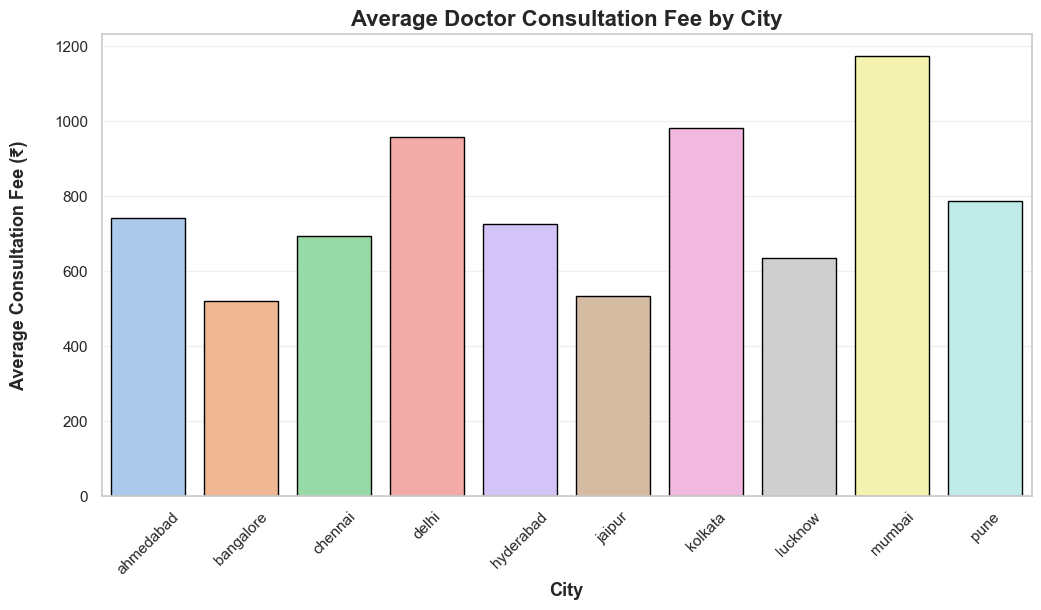

In [169]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))


# Creating a bar plot to compare average consultation fees across cities
sns.barplot(
    x=city_fee_stats.index,
    y=city_fee_stats["Average_Fee"],
    palette= "pastel", # viridis/flare/pastel
    edgecolor="black"
)

plt.title("Average Doctor Consultation Fee by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13, fontweight="bold")
plt.ylabel("Average Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45) # Rotate city name to prevent overlapping
plt.grid(axis='y', alpha=0.3) # Added light grid lines to improve readability of values
plt.show()

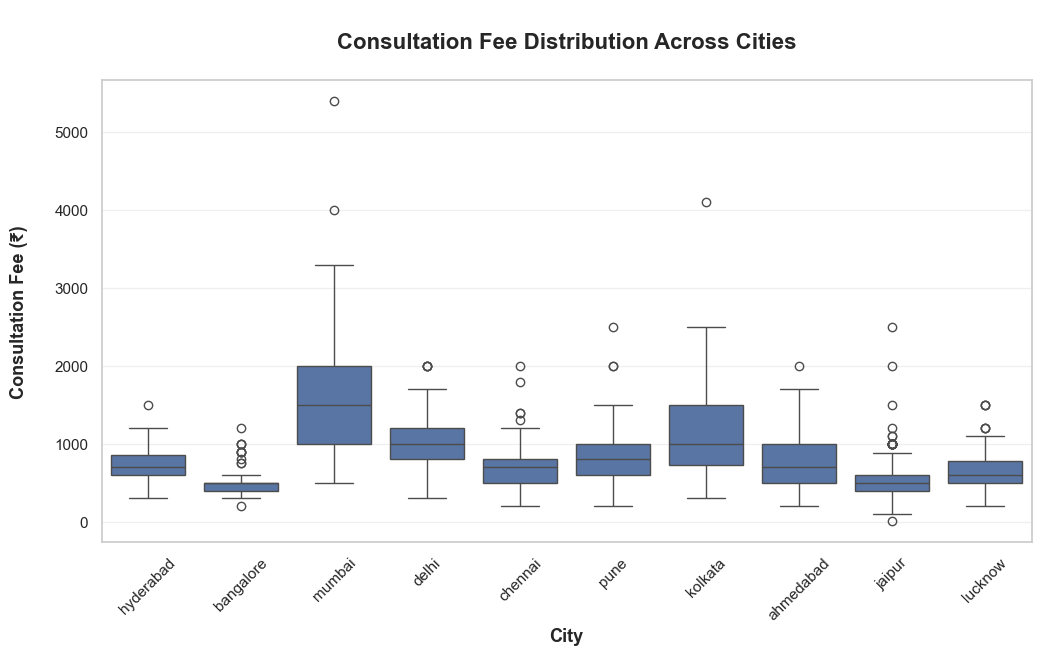

In [170]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="City",
    y="Consultation_Fee"
)

plt.title("\nConsultation Fee Distribution Across Cities\n", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Key Insights:
1. The Most Expensive Cities

    Mumbai is the most expensive city for healthcare, with an average fee of ₹1,174.

    Kolkata and Delhi follow closely, both averaging near ₹1,000 per visit.

2. The Most Affordable Cities

    Bangalore and Jaipur are the most budget-friendly, with average fees around ₹520–₹534.

    The most common (median) price in these cities is just ₹500.

    Patna is also noted as a highly affordable market for healthcare access.

3. Pricing Gaps (High vs. Low)

    Huge Variety: In Mumbai, fees can range from ₹500 to over ₹5,000, meaning there is a massive difference between a local clinic and a premium specialist.

    Consistency: Cities like Hyderabad and Bangalore have much "tighter" pricing, meaning most doctors charge a similar, predictable rate.

4. Supply vs. Cost

    Having more doctors doesn't always make it cheaper.

    Jaipur has the most doctors (178) and is very cheap.

    However, Pune also has many doctors (177) but charges much higher rates (₹788 average), likely due to a higher cost of living.

### **3. SPECIALIZATION-WISE PRICING STATISTICS**

**A) Calculate Average Fee, Median Fee, Standard Deviation, Min, Max, Doctor Count.**

In [171]:
# with outliers in consultation fee
spec_fee_stats = df.groupby("Specialization")["Consultation_Fee"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Std_Deviation="std",
    Min_Fee="min",
    Max_Fee="max",
    Doctors="count"
).round(2)

spec_fee_stats.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
Specialization,,,,,,
Psychologist,2250.00,2250.0,353.55,2000.0,2500.0,2
Diabetologist,2000.00,2000.0,NaN,2000.0,2000.0,1
Cardiac Surgeon,1640.00,2000.0,589.92,1000.0,2200.0,5
Electrotherapist,1500.00,1500.0,NaN,1500.0,1500.0,1
Reproductive Endocrinologist (Infertility),1500.00,1500.0,NaN,1500.0,1500.0,1
Psychiatrist,1431.25,1400.0,716.21,500.0,3000.0,16
Spine Surgeon,1423.08,1300.0,641.81,600.0,2500.0,13
Endocrine Surgeon,1400.00,1400.0,NaN,1400.0,1400.0,1
Cardiothoracic Surgeon,1360.00,800.0,1101.36,700.0,3300.0,5


In [172]:
# without outliers
spec_fee_stats_filt = df_no_outliers.groupby("Specialization")["Consultation_Fee"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Std_Deviation="std",
    Min_Fee="min",
    Max_Fee="max",
    Doctors="count"
).round(2)

spec_fee_stats_filt.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors
Specialization,,,,,,
Electrotherapist,1500.00,1500.00,NaN,1500.0,1500.0,1
Reproductive Endocrinologist (Infertility),1500.00,1500.00,NaN,1500.0,1500.0,1
Endocrine Surgeon,1400.00,1400.00,NaN,1400.0,1400.0,1
Rehab & Physical Medicine Specialist,1200.00,1200.00,NaN,1200.0,1200.0,1
Spine Surgeon,1130.00,1150.00,359.17,600.0,1600.0,10
Hematologist,1100.00,1100.00,NaN,1100.0,1100.0,1
Spine And Pain Specialist,1080.00,1200.00,327.11,700.0,1500.0,5
Dermatologist,1058.75,1000.00,337.58,500.0,1700.0,40
Psychiatrist,1036.36,900.00,374.89,500.0,1500.0,11


C:\Users\suvarna\AppData\Local\Temp\ipykernel_26724\300967526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='Consultation_Fee', y='Specialization', palette='coolwarm')


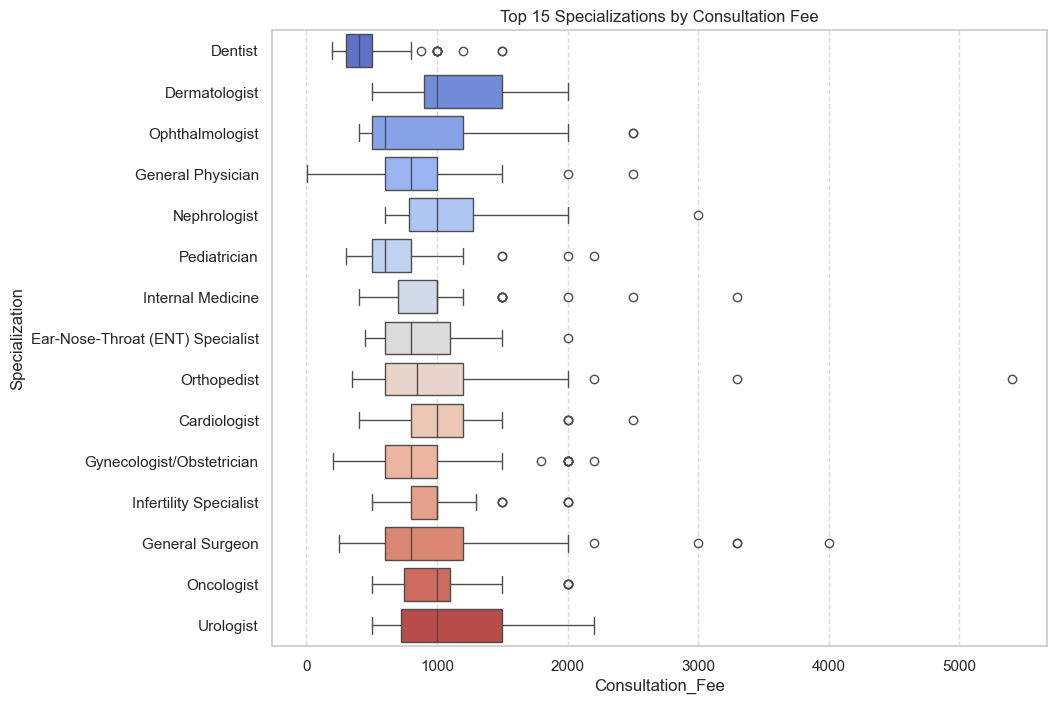

In [173]:
# Filter for the top 15 most common specializations to reduce noise
top_specs = df['Specialization'].value_counts().nlargest(15).index
filtered_df = df[df['Specialization'].isin(top_specs)]

plt.figure(figsize=(10, 8))
# Switching to a horizontal plot (y='Specialization') makes it readable
sns.boxplot(data=filtered_df, x='Consultation_Fee', y='Specialization', palette='coolwarm')

plt.title('Top 15 Specializations by Consultation Fee')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**B) Identify Premium vs Budget Specializations:**

In [174]:
spec_fee_stats["Variance"] = df.groupby("Specialization")["Consultation_Fee"].var().round(2)
spec_fee_stats.sort_values(by="Variance", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance
Specialization,,,,,,,
Anesthesiologist,1350.00,850.0,1107.70,500.0,3300.0,6,1227000.00
Cardiothoracic Surgeon,1360.00,800.0,1101.36,700.0,3300.0,5,1213000.00
Gastroenterologist,983.33,800.0,891.96,300.0,4100.0,18,795588.24
Pain Management Specialist,1133.33,800.0,757.19,600.0,2000.0,3,573333.33
Psychiatrist,1431.25,1400.0,716.21,500.0,3000.0,16,512958.33
General Surgeon,1055.84,800.0,705.94,250.0,4000.0,77,498353.55
Orthopedist,1034.53,850.0,697.05,350.0,5400.0,92,485884.52
Spine Surgeon,1423.08,1300.0,641.81,600.0,2500.0,13,411923.08
Cardiac Surgeon,1640.00,2000.0,589.92,1000.0,2200.0,5,348000.00


In [175]:
# With free consultance fee

premium_specialization = spec_fee_stats["Average_Fee"].idxmax()
budget_specialization = spec_fee_stats["Average_Fee"].idxmin()

print(f"\nPremium Specialization: {premium_specialization}")
print(f"Most Affordable Specialization: {budget_specialization}\n")


Premium Specialization: Psychologist
Most Affordable Specialization: Dentist



In [176]:
df_paid = df[df["Consultation_Fee"] > 0]
spec_fee_stats_paid = df_paid.groupby("Specialization")["Consultation_Fee"].agg(
    Average_Fee = "mean",
    Median_Fee = "median",
    Std_Deviation = "std",
    Min_Fee = "min",
    Max_Fee = "max",
    Doctors = "count"
).round(2)

spec_fee_stats_paid["Variance"] = df_paid.groupby("Specialization")["Consultation_Fee"].var().round(2)

spec_fee_stats_paid.sort_values(by="Variance", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance
Specialization,,,,,,,
Anesthesiologist,1350.00,850.0,1107.70,500.0,3300.0,6,1227000.00
Cardiothoracic Surgeon,1360.00,800.0,1101.36,700.0,3300.0,5,1213000.00
Gastroenterologist,983.33,800.0,891.96,300.0,4100.0,18,795588.24
Pain Management Specialist,1133.33,800.0,757.19,600.0,2000.0,3,573333.33
Psychiatrist,1431.25,1400.0,716.21,500.0,3000.0,16,512958.33
General Surgeon,1055.84,800.0,705.94,250.0,4000.0,77,498353.55
Orthopedist,1034.53,850.0,697.05,350.0,5400.0,92,485884.52
Spine Surgeon,1423.08,1300.0,641.81,600.0,2500.0,13,411923.08
Cardiac Surgeon,1640.00,2000.0,589.92,1000.0,2200.0,5,348000.00


In [177]:
# Without free consultance fee

premium_specialization = spec_fee_stats_paid["Average_Fee"].idxmax()
budget_specialization = spec_fee_stats_paid["Average_Fee"].idxmin()

print(f"\nPremium Specialization: {premium_specialization}")
print(f"Most Affordable Specialization: {budget_specialization}\n")


Premium Specialization: Psychologist
Most Affordable Specialization: Dentist



In [178]:
# Since we have to add variance, so we have to go without free consultancy fee for better observation.

spec_fee_stats_paid["Price_Level"] = pd.qcut(
    spec_fee_stats_paid["Average_Fee"],
    q=3,
    labels=["Budget", "Moderate", "Premium"]
)

spec_fee_stats_paid.sort_values(by="Average_Fee", ascending=False)

,Average_Fee,Median_Fee,Std_Deviation,Min_Fee,Max_Fee,Doctors,Variance,Price_Level
Specialization,,,,,,,,
Psychologist,2250.00,2250.0,353.55,2000.0,2500.0,2,125000.00,Premium
Diabetologist,2000.00,2000.0,NaN,2000.0,2000.0,1,NaN,Premium
Cardiac Surgeon,1640.00,2000.0,589.92,1000.0,2200.0,5,348000.00,Premium
Electrotherapist,1500.00,1500.0,NaN,1500.0,1500.0,1,NaN,Premium
Reproductive Endocrinologist (Infertility),1500.00,1500.0,NaN,1500.0,1500.0,1,NaN,Premium
Psychiatrist,1431.25,1400.0,716.21,500.0,3000.0,16,512958.33,Premium
Spine Surgeon,1423.08,1300.0,641.81,600.0,2500.0,13,411923.08,Premium
Endocrine Surgeon,1400.00,1400.0,NaN,1400.0,1400.0,1,NaN,Premium
Cardiothoracic Surgeon,1360.00,800.0,1101.36,700.0,3300.0,5,1213000.00,Premium


### Complete Insights of Specialization-Wise Pricing Analysis
**Insight-01 — Premium Specializations**

    Certain medical fields command the highest consultation fees due to the specialized nature of the care.
    
    Psychologists emerge as the most premium specialization with the highest average fees in this dataset.

    Other high-cost segments include Cardiac Surgeons (₹1,640 avg) and Spine Surgeons (₹1,423 avg), indicating that surgical and mental health services occupy the top tier of the market.

**Insight-02 — Budget-Friendly Specializations**

    Routine and high-volume care sectors offer the most accessible pricing for patients.

    Dentists are identified as the most affordable specialization.

    Homoeopaths and Ophthalmologists also maintain lower average and median fees (around ₹500–₹600), making them more accessible for routine medical care.

**Insight-03 — High Fee Variability (Pricing Uncertainty)**

    The variance analysis shows that price predictability changes drastically depending on the doctor's field.

    Anesthesiologists and Cardiothoracic Surgeons show the highest Variance and Standard Deviation (over ₹1,100).

    This massive spread suggests that prices in these fields are not standardized and may depend heavily on the complexity of the case or the doctor's individual experience level.

**Insight-04 — Market Segmentation**

    The data reveals a clear "split" in the healthcare market:

    High-End Segment: Surgical and specialized diagnostic fields (e.g., Gastroenterologists, Psychiatrists) where the median fee is often ₹800 or higher.

    Value Segment: General wellness and routine care (e.g., Dietitians, Dentists) where the floor price starts as low as ₹200–₹300.

**Insight-05 — Impact of "Free" Consultations**

    The analysis compared data both with and without "free" consultation entries.

    Excluding free consultations did not change the overall ranking—Psychologists remained the most expensive and Dentists remained the most affordable. This indicates that the pricing structure for these specializations is consistent across the platform regardless of promotional offers.

<h1 align=center>PHASE-02: FACTOR IMPACT ANALYSIS </h1>

### POINT OF DISCUSSION & ANALYSIS:
1. Experience-wise Pricing Analysis
2. Patient Rating-wise Pricing Analysis

**1. Experience Vs Consultation Fee:**

**A) Correlation (Pearson) Between Exprience and Consultation Fee**

In [179]:
print(df[["Experience_in_years","Consultation_Fee"]].corr())

corr_value = df["Experience_in_years"].corr(df["Consultation_Fee"])
print(f"\nPearson Correlation between Experience and Consultation Fee: {corr_value:.3f}\n")

                     Experience_in_years  Consultation_Fee
Experience_in_years             1.000000          0.160152
Consultation_Fee                0.160152          1.000000

Pearson Correlation between Experience and Consultation Fee: 0.160



**B) Visualization: Scatter Plot with Regression Line**

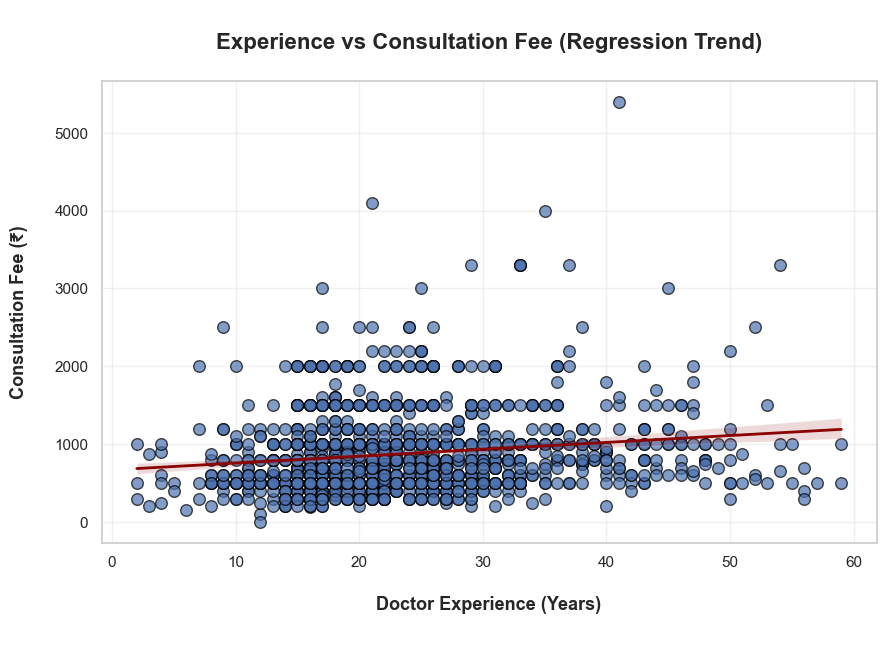

In [180]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))


# Creating a regression plot to analyze the relationship
# between doctor experience and consultation fee
sns.regplot(
    data=df,
    x="Experience_in_years",
    y="Consultation_Fee",
    
    # Customize the scatter points
    scatter_kws={
        "alpha":0.7,        # Slight transparency to reduce overlap
        "s":70,             # Marker size
        "color":"#4C72B0",  # Professional blue color
        "edgecolor":"black" # Black border around points
    },
    
    # Customize the regression trend line
    line_kws={
        "color":"darkred",  # Trend line color
        "linewidth":2       # Thickness of the regression line
    }
)

plt.title("\nExperience vs Consultation Fee (Regression Trend)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nDoctor Experience (Years)\n", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()


### Key Insights:
1. Experience vs Consultation Fee
- The Data: The Pearson Correlation value is only 0.160.
- The Insight: Experience has a very weak positive influence on pricing. While fees tend to go up slightly as years of experience increase, it is not a strong or reliable predictor of what a doctor will charge.

2. High Price Variation
- The Data: The scatter plot shows a dense cloud of data points across all experience levels.
- The Insight: Doctors with the same years of experience charge drastically different amounts. For example, doctors with 20 years of experience might charge anywhere from ₹300 to over ₹1,500. Experience alone does not set the price.

3. Presence of "Premium Outliers"
- The Data: Several points sit far above the red regression line (reaching ₹3,000–₹5,000).
- The Insight: Some doctors charge "super-premium" fees regardless of their experience. A doctor with only 10 years of experience can sometimes charge more than a veteran with 40 years, likely due to their specialization, hospital brand, or reputation.

4. The "Market Middle" (10–30 Years)
- The Data: The highest concentration of doctors falls between 10 and 30 years of experience.
- The Insight: Most of the healthcare market is made up of mid-career doctors who charge a "standard" fee between ₹400 and ₹1,000. This is the most competitive and common price bracket.

5. Experience Is Not the Main Driver
- The Conclusion: Since the relationship is so weak (0.160), other factors are clearly more important in determining fees.
- Other Factors: City (location), Specialization (type of doctor), and Hospital Reputation play a much larger role in the final bill than the number of years a doctor has practiced.

**2. Patient Rating Vs Consultation Fee:**

**A) Correlation (Pearson) Patient Rating and Consultation Fee**

In [181]:
print(df[["Patient_Rating","Consultation_Fee"]].corr())

corr_value02 = df["Patient_Rating"].corr(df["Consultation_Fee"])
print(f"\nPearson Correlation between Patient Rating and Consultation Fee: {corr_value02:.3f}\n")

                  Patient_Rating  Consultation_Fee
Patient_Rating          1.000000         -0.029113
Consultation_Fee       -0.029113          1.000000

Pearson Correlation between Patient Rating and Consultation Fee: -0.029



**B) Visualization: Scatter Plot with Regression Line**

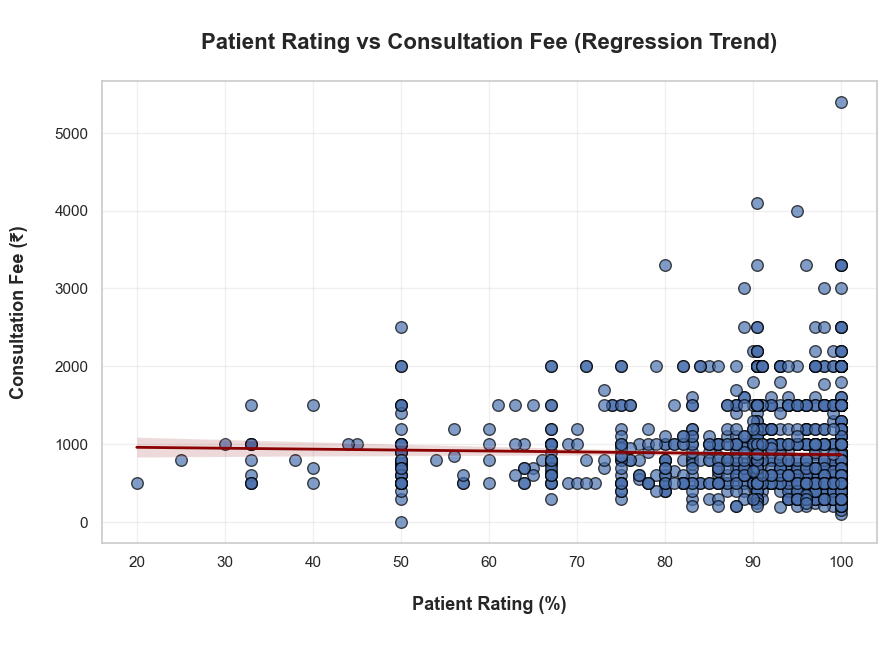

In [182]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Patient_Rating",
    y="Consultation_Fee",
    
    # Customize the scatter points
    scatter_kws={
        "alpha":0.7,        # Slight transparency to reduce overlap
        "s":70,             # Marker size
        "color":"#4C72B0",  # Professional blue color
        "edgecolor":"black" # Black border around points
    },
    
    # Customize the regression trend line
    line_kws={
        "color":"darkred",  # Trend line color
        "linewidth":2       # Thickness of the regression line
    }
)

plt.title("\nPatient Rating vs Consultation Fee (Regression Trend)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nPatient Rating (%)\n", fontsize=13, fontweight="bold")
plt.ylabel("Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()

### Key Insights:
1. Minimal Impact of Doctor Reputation on Price
- The Data: The Pearson Correlation is -0.029 (virtually zero).
- The Insight: A doctor’s reputation, as measured by patient ratings, has almost no influence on their consultation fee. Highly-rated doctors are just as likely to charge low fees as they are to charge premium rates.
2. Ratings Do Not Guarantee Higher Fees
- The Data: The scatter plot shows a massive cluster of doctors with 90–100% ratings charging a wide variety of prices, from ₹200 to ₹5,000.
- The Insight: Patient satisfaction does not translate into pricing power. You can find "top-rated" doctors in every price bracket, meaning patients don't necessarily have to pay more for a highly-recommended professional.
3. Counter-Intuitive Pricing Trend
- The Data: The regression line shows a slight downward (negative) slope.
- The Insight: There is a minor trend where higher-rated doctors sometimes charge less than lower-rated ones. This confirms that rating is not a driver for price hikes and suggests that affordable doctors often provide highly satisfactory experiences.
4. Consistent Variation Across All Ratings
- The Data: Even at lower rating levels (e.g., 50%), the fee variation remains high.
- The Insight: Whether a doctor is rated poorly or perfectly, their pricing decisions seem to be driven by external factors—such as their city, hospital affiliation, or specialization—rather than their standing with patients.

**C) Group Doctors by Rating Level**

In [184]:
df_no_outliers.loc[:,"Rating_Group"] = df_no_outliers["Patient_Rating"].apply(lambda x: "High Rated" if x >= 90 else "Lower Rated")

In [185]:
df_no_outliers["Rating_Group"].value_counts()

Rating_Group
High Rated     916
Lower Rated    306
Name: count, dtype: int64

**D) Group Doctors by Rating Level and [Avg_Fee, Median_Fee, Number of Doctors]**

In [187]:
rating_fee = df_no_outliers.groupby("Rating_Group")["Consultation_Fee"].agg(
    Average_Fee="mean",
    Median_Fee="median",
    Doctors="count"
).round(2)

rating_fee

,Average_Fee,Median_Fee,Doctors
Rating_Group,,,
High Rated,757.03,700.0,916
Lower Rated,823.91,800.0,306


**Visualization: Average Consultation Fee by Doctor Rating Group:**

C:\Users\suvarna\AppData\Local\Temp\ipykernel_26724\311984892.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\suvarna\AppData\Local\Temp\ipykernel_26724\311984892.py:4: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(


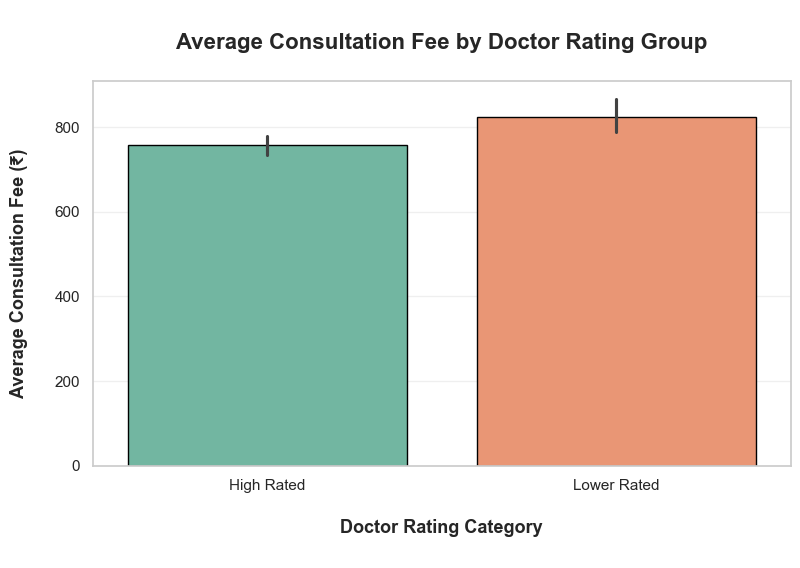

In [188]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))

sns.barplot(
    x="Rating_Group",
    y="Consultation_Fee",
    data=df_no_outliers,
    palette=sns.color_palette("Set2"),
    edgecolor="black"
)

plt.title("\nAverage Consultation Fee by Doctor Rating Group\n", fontsize=16, fontweight="bold")
plt.xlabel("\nDoctor Rating Category\n", fontsize=13, fontweight="bold")
plt.ylabel("Average Consultation Fee (₹)\n", fontsize=13, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.show()

## **2. Correlation Between Key Variables: Exprience, Patient Rating(%) and Consultation Fee:**

**A) Visualization: HEATMAP**

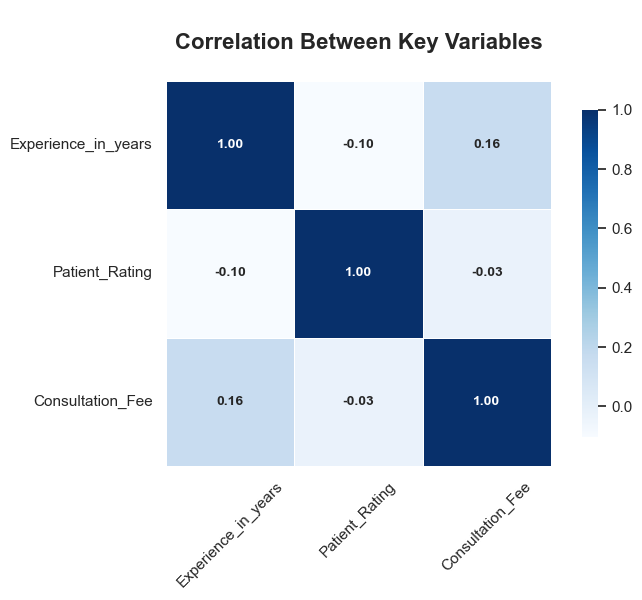

In [189]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

# Creating a correlation heatmap to visualize relationships between variables
sns.heatmap(
    
    # Computing correlation matrix for selected numerical columns
    df[["Experience_in_years","Patient_Rating","Consultation_Fee"]].corr(),
    
    # Display correlation values inside each cell
    annot=True,
    
    # Format correlation values to two decimal places
    fmt=".2f",
    
    # Use a diverging color palette to show positive vs negative correlation
    cmap="Blues",
    
    # Added borders between cells for better clarity
    linewidths=0.5,
    linecolor="white",
    
    # Make cells square-shaped for better visual symmetry
    square=True,
    
    # Added a color bar to indicate correlation scale
    cbar_kws={"shrink":0.85},
    annot_kws={"size":10, "weight":"bold"}
)

plt.title("\nCorrelation Between Key Variables\n", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [87]:
corr_table = df[["Experience_in_years", "Patient_Rating", "Consultation_Fee"]].corr()

corr_table

,Experience_in_years,Patient_Rating,Consultation_Fee
Experience_in_years,1.000000,-0.103441,0.160152
Patient_Rating,-0.103441,1.000000,-0.029113
Consultation_Fee,0.160152,-0.029113,1.000000


<h1 align=center>PHASE-03: MULTI-FACTOR COMPARATIVE ANALYSIS</h1?

### POINT OF DISCUSSION & ANALYSIS:
**1. City & Specialization-wise Pricing Analysis**

**2. Premium Segment Pricing Analysis**

**1. CITY & SPECIALIZATION-WISE PRICING ANALYSIS**

**A) PIVOT TABLE: CITY (vs) SPECIALIZATION**

In [125]:
pivot_city_spec = pd.pivot_table(
    df_no_outliers,
    values="Consultation_Fee",
    index="City",
    columns="Specialization",
    aggfunc="mean"
).round(0)

pivot_city_spec

Specialization,Ayurveda,Homoeopath,Sexologist,Anesthesiologist,Audiologist,Bariatric Surgeon,Cardiac Surgeon,Cardiologist,Cardiothoracic Surgeon,Clinical Pharmacologist and Toxicologist,...,Pulmonologist,Radiologist,Rehab & Physical Medicine Specialist,Reproductive Endocrinologist (Infertility),Reproductive Medicine and Infertility,Sexologist,Spine And Pain Specialist,Spine Surgeon,Urologist,Vascular Surgeon
City,,,,,,,,,,,,,,,,,,,,,
ahmedabad,500.0,700.0,NaN,NaN,800.0,NaN,NaN,NaN,NaN,NaN,...,500.0,NaN,NaN,NaN,NaN,1500.0,900.0,NaN,1000.0,NaN
bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1200.0,NaN,NaN,NaN
chennai,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,864.0,800.0,NaN,...,850.0,NaN,NaN,NaN,NaN,NaN,NaN,950.0,740.0,900.0
delhi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,NaN,NaN,...,NaN,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hyderabad,NaN,NaN,NaN,550.0,NaN,1100.0,NaN,850.0,800.0,NaN,...,733.0,750.0,NaN,NaN,800.0,NaN,NaN,800.0,700.0,1200.0
jaipur,NaN,633.0,NaN,NaN,NaN,NaN,NaN,567.0,700.0,NaN,...,500.0,200.0,NaN,NaN,NaN,900.0,NaN,850.0,525.0,NaN
kolkata,567.0,500.0,NaN,1100.0,NaN,NaN,NaN,1000.0,NaN,500.0,...,1500.0,NaN,1200.0,NaN,NaN,NaN,NaN,NaN,1286.0,NaN
lucknow,610.0,440.0,500.0,NaN,NaN,NaN,NaN,800.0,NaN,NaN,...,800.0,1000.0,NaN,NaN,NaN,800.0,NaN,NaN,725.0,NaN
mumbai,NaN,1500.0,NaN,600.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1500.0,NaN,NaN,1500.0,1400.0,1475.0,NaN


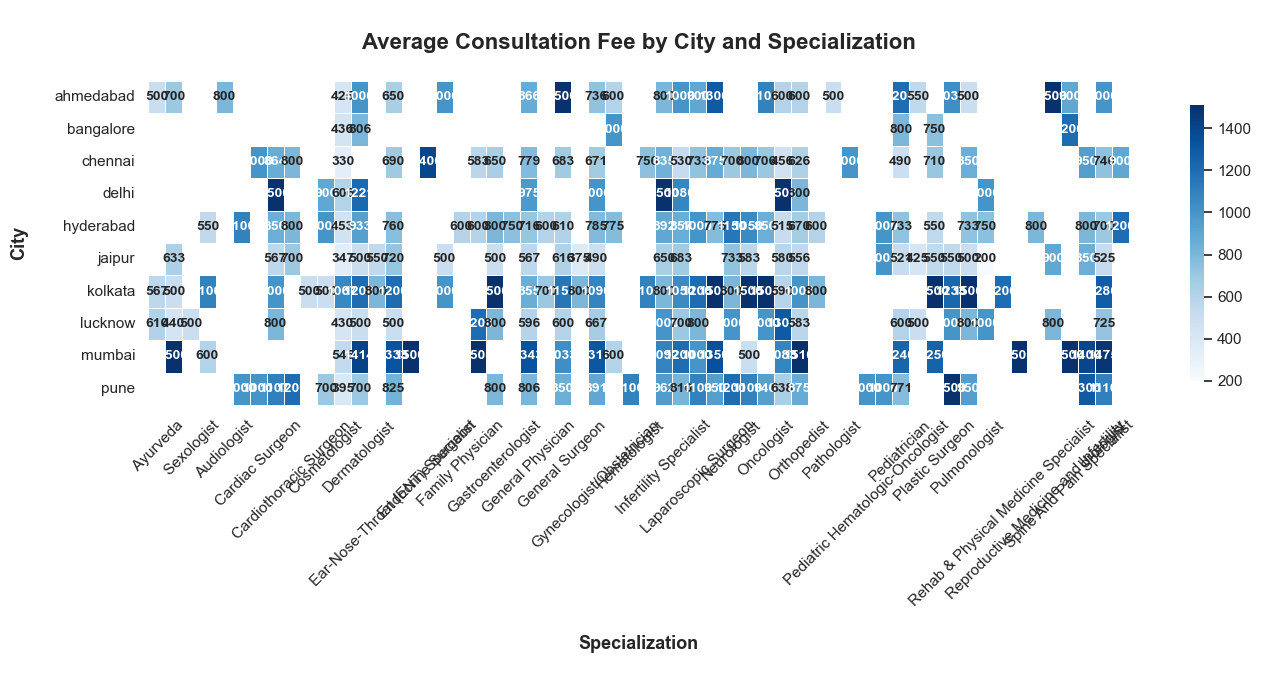

In [126]:
sns.set_theme(style="white")
plt.figure(figsize=(14,7))
ax = sns.heatmap(
    pivot_city_spec,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    square=False,
    cbar_kws={"shrink":0.85},
    annot_kws={"size":10, "weight":"bold"}
)

plt.title("\nAverage Consultation Fee by City and Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("City\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
# 1. Identify the top 10 specializations by doctor count
top_10_specializations = df_no_outliers['Specialization'].value_counts().nlargest(10).index

# 2. Filter the dataframe and create the pivot table
pivot_city_spec = pd.pivot_table(
    df_no_outliers[df_no_outliers['Specialization'].isin(top_10_specializations)],
    values="Consultation_Fee",
    index="City",
    columns="Specialization",
    aggfunc="mean"
).round(0)

# Display the updated pivot table
pivot_city_spec

Specialization,Dentist,Dermatologist,General Physician,General Surgeon,Gynecologist/Obstetrician,Infertility Specialist,Internal Medicine,Ophthalmologist,Orthopedist,Pediatrician
City,,,,,,,,,,
ahmedabad,425.0,1000.0,866.0,1500.0,736.0,800.0,1000.0,600.0,600.0,1200.0
bangalore,436.0,806.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
chennai,330.0,NaN,779.0,683.0,671.0,835.0,530.0,456.0,626.0,490.0
delhi,606.0,1221.0,975.0,NaN,1000.0,1500.0,1080.0,1500.0,800.0,NaN
hyderabad,453.0,933.0,716.0,610.0,785.0,892.0,857.0,515.0,670.0,733.0
jaipur,347.0,500.0,567.0,616.0,490.0,650.0,683.0,580.0,556.0,521.0
kolkata,1067.0,1200.0,855.0,1153.0,1090.0,800.0,1050.0,590.0,1004.0,NaN
lucknow,430.0,500.0,596.0,600.0,667.0,1000.0,700.0,1300.0,583.0,600.0
mumbai,545.0,1414.0,1343.0,1033.0,1314.0,1092.0,1200.0,1083.0,1510.0,1240.0


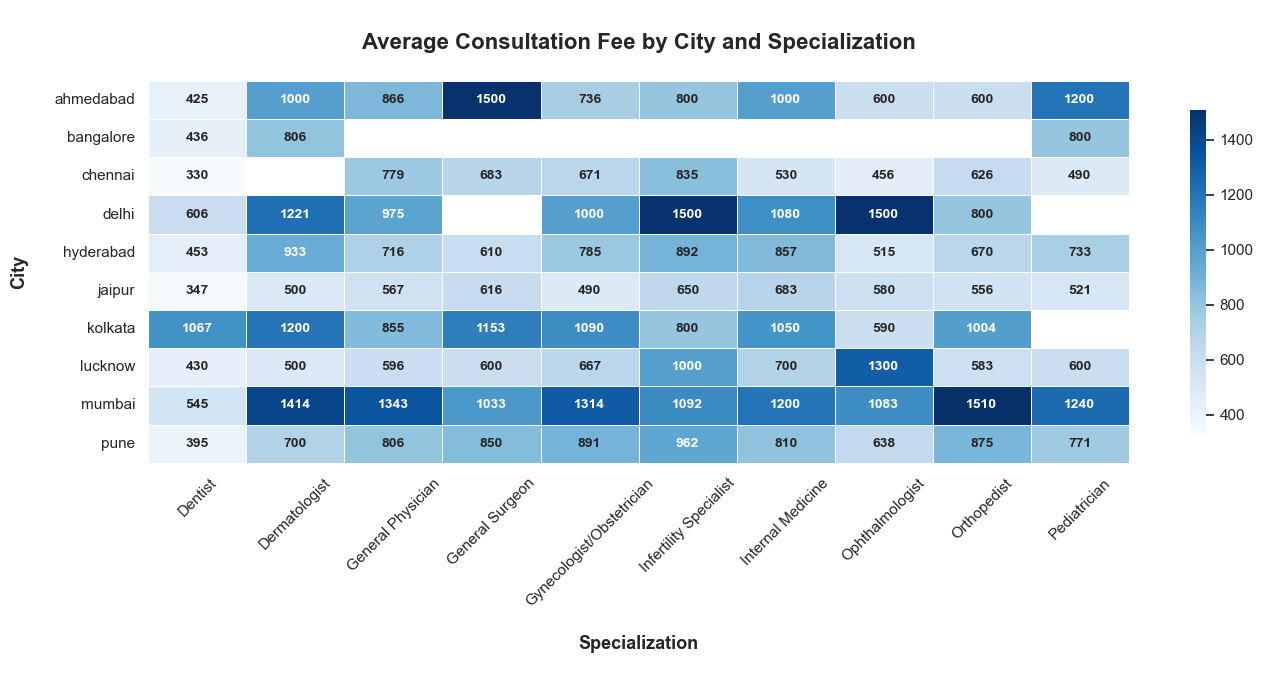

In [10]:
import seaborn as sns
sns.set_theme(style="white")
plt.figure(figsize=(14,7))
ax = sns.heatmap(
    pivot_city_spec,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    square=False,
    cbar_kws={"shrink":0.85},
    annot_kws={"size":10, "weight":"bold"}
)

plt.title("\nAverage Consultation Fee by City and Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("City\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [127]:
# SPECIFIC COMPARISON:
# i) Identify Most Expensive City–Specialization Pair:

pivot_city_spec.stack().idxmax()

('mumbai', 'Orthopedist')

In [128]:
# ii) Identify Most Affordable Pair
pivot_city_spec.stack().idxmin()

('jaipur', 'Radiologist')

In [129]:
# iii)Cardiologist Hyderabad vs Delhi
pivot_city_spec.loc[["hyderabad","delhi"],"Cardiologist"]

City
hyderabad     850.0
delhi        1500.0
Name: Cardiologist, dtype: float64

In [130]:
# Additional Insight Table
# This ranks cities by overall healthcare pricing level.
pivot_city_spec.mean(axis=1).sort_values(ascending=False)

City
mumbai       1199.250000
delhi        1098.363636
kolkata      1033.181818
pune          951.034483
ahmedabad     856.153846
bangalore     832.000000
hyderabad     786.305556
chennai       753.607143
lucknow       748.115385
jaipur        581.758621
dtype: float64

### Key Insights
1. Significant Pricing Variation Across Cities
 - The heatmap shows that the same medical specialization charges different consultation fees in different cities,
   indicating strong regional pricing differences in urban healthcare markets.

2. Certain Cities Act as Premium Healthcare Markets
 - Some cities like Mumbai, Delhi, and Kolkata consistently display higher consultation fees across multiple specializations,
   suggesting the presence of premium healthcare ecosystems.

3. Specialization Pricing Is Not Uniform Nationwide
 - For the same specialization (e.g., Cardiologist), consultation fees vary across cities, highlighting that local market conditions
   influence healthcare pricing.

4. Premium Healthcare Clusters Exist
 - The heatmap visually reveals clusters where specific city–specialization combinations command significantly higher fees,
   indicating localized demand for specialized healthcare services.

**2. PREMIUM SEGMENT PRICING ANALYSIS**

In [103]:
premium_threshold = df["Consultation_Fee"].quantile(0.75)
premium_threshold

np.float64(1000.0)

In [107]:
premium_doctors = df[df["Consultation_Fee"] >= premium_threshold]
premium_doctors.head()

,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Rating_Group
14,Dr. Sanjay Sakhamuri,Sasha Luxe Dermatology and Cosmetic Surgery Ce...,hyderabad,Cosmetologist,15,1000.0,100.000000,34,High Rated
15,Dr. Navya Chowdary,Sasha Luxe Dermatology and Cosmetic Surgery Ce...,hyderabad,Dermatologist,16,1000.0,87.000000,68,Lower Rated
18,Dr. M S Gowd,Dr. Gowd's Dental Hospital,hyderabad,Dentist,59,1000.0,97.000000,34,High Rated
19,Dr. Vuyyuru Manjula Priya Darshini,Sikara Clinics,hyderabad,Dermatologist,27,1000.0,90.380783,161,High Rated
33,Dr. Rahul Gandhi Godisela,Medicover Hospital,hyderabad,General Physician,22,1000.0,92.000000,61,High Rated


In [105]:
# Number of doctors belonging to premium segment
premium_doctors.shape

(482, 9)

In [106]:
# premium segment doctors by city
premium_city = premium_doctors["City"].value_counts()
premium_city

City
mumbai       154
kolkata      101
pune          62
delhi         35
chennai       31
hyderabad     31
ahmedabad     27
jaipur        23
lucknow       14
bangalore      4
Name: count, dtype: int64

#### VISUALIZATION: Number of Premium Doctors (vs) City

C:\Users\suvarna\AppData\Local\Temp\ipykernel_26724\3012089312.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


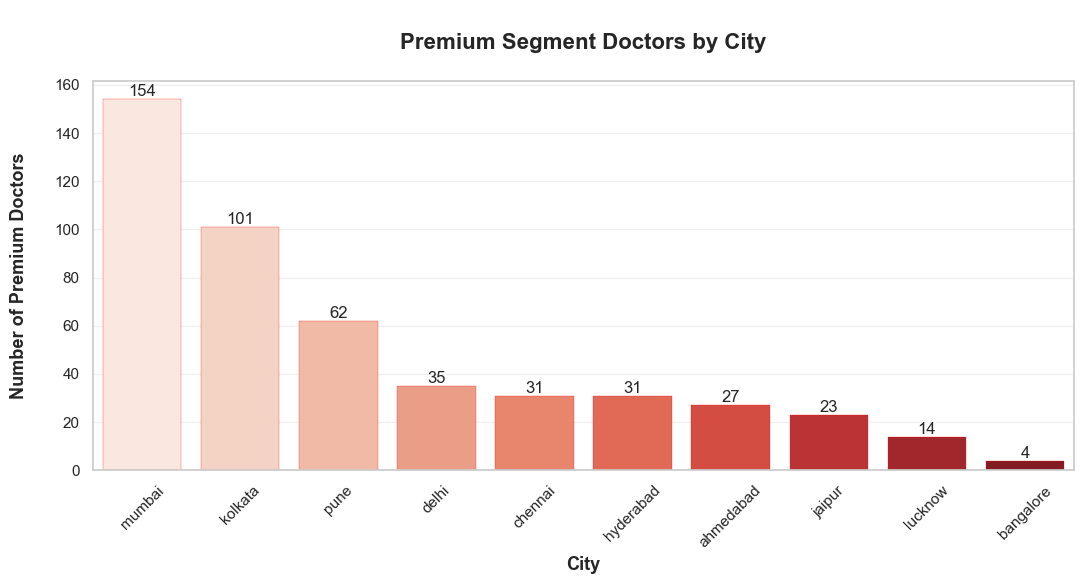

In [108]:
# Visualidation

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11,6))
palette = sns.color_palette("Reds", n_colors=premium_doctors["City"].nunique())
ax = sns.countplot(
    data=premium_doctors,
    x="City",
    order=premium_doctors["City"].value_counts().index,
    palette=palette,
    edgecolor="Red",
    linewidth=0.2
)

plt.title("\nPremium Segment Doctors by City\n", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13, fontweight="bold")
plt.ylabel("Number of Premium Doctors\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

**VISUALIZATION: Number of Premium Doctors (vs) Specialization**

In [109]:
# Specialization which Dominates Premium Segment

premium_specialization = premium_doctors["Specialization"].value_counts()
premium_specialization

Specialization
General Physician                             59
Orthopedist                                   38
Gynecologist/Obstetrician                     37
General Surgeon                               35
Dermatologist                                 30
Ophthalmologist                               27
Internal Medicine                             25
Infertility Specialist                        23
Cardiologist                                  21
Urologist                                     19
Ear-Nose-Throat (ENT) Specialist              18
Oncologist                                    14
Nephrologist                                  14
Spine Surgeon                                 10
Pediatrician                                  10
Psychiatrist                                  10
Dentist                                        9
Laparoscopic Surgeon                           7
Pulmonologist                                  7
Plastic Surgeon                                6
Neuro

C:\Users\suvarna\AppData\Local\Temp\ipykernel_26724\279109624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


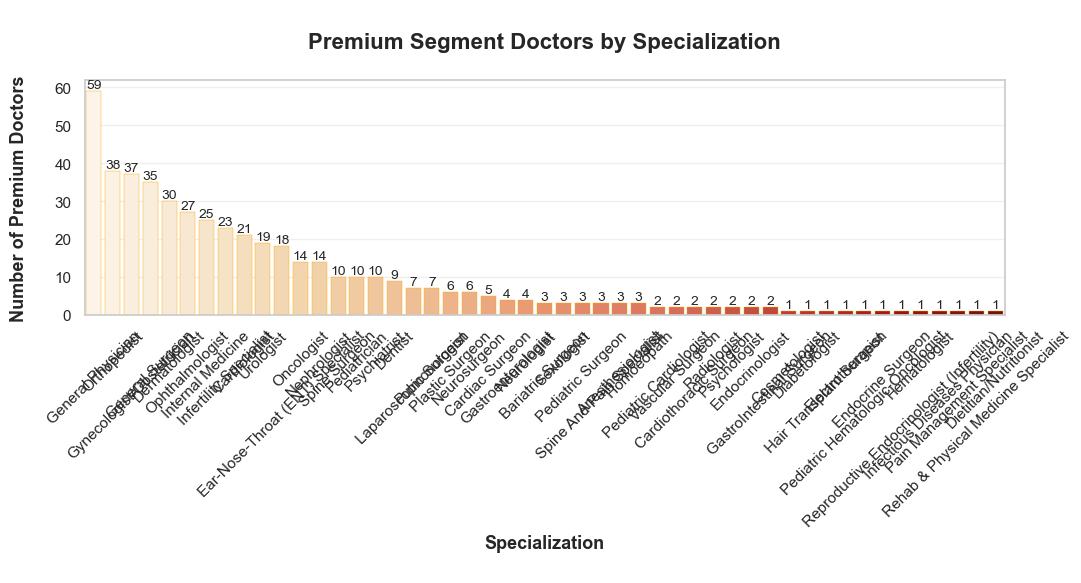

In [110]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11,6))
# palette = sns.color_palette("Greens", n_colors=premium_doctors["Specialization"].nunique())
ax = sns.countplot(
    data=premium_doctors,
    x="Specialization",
    order=premium_doctors["Specialization"].value_counts().index,
    palette="OrRd",
    edgecolor="Orange",
    linewidth=0.3
)

plt.title("\nPremium Segment Doctors by Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("Specialization\n", fontsize=13, fontweight="bold")
plt.ylabel("Number of Premium Doctors\n", fontsize=13, fontweight="bold")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

**City × Specialization Premium Heatmap**

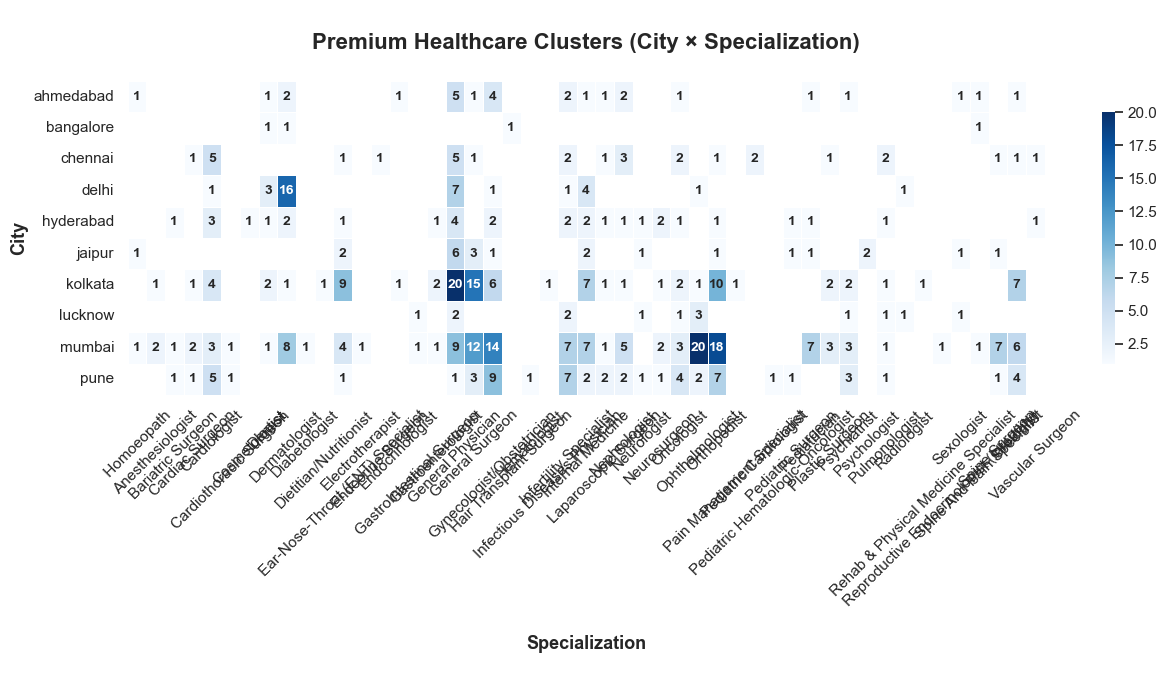

In [111]:
sns.set_theme(style="white")
premium_pivot = pd.pivot_table(
    premium_doctors,
    values="Consultation_Fee",
    index="City",
    columns="Specialization",
    aggfunc="count"
)

plt.figure(figsize=(13,7))

ax = sns.heatmap(
    premium_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink":0.8},
    annot_kws={"size":10,"weight":"bold"}
)

plt.title("\nPremium Healthcare Clusters (City × Specialization)\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("City", fontsize=13, fontweight="bold")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Premium Segment Analysis (Fees ≥ ₹1000)
**Insight-01 — Market Concentration in Mumbai & Kolkata**
- The Insight: Premium healthcare providers are not evenly distributed; they are heavily concentrated in specific financial and cultural hubs.
- The Data: Mumbai leads the country with 154 premium doctors, followed by Kolkata with 101. Together, these two cities house more than half of the total premium segment, indicating a massive demand for high-end medical services in these regions.

**Insight-02 — Specialization "Leaders" in the Premium Tier**
- The Insight: Routine and primary care roles actually dominate the volume of the premium segment, while surgeons dominate the price.
- The Data: General Physicians (59), Orthopedists (38), and Gynecologists (37) are the most frequent specializations in the top-fee bracket. This suggests that for these common fields, patients are willing to pay a significant premium for established names or luxury hospital settings.

**Insight-03 — Urban "Power Clusters"**
- The Insight: The heatmap reveals specific city-specialization combinations that act as "Premium Clusters."
- The Data: * Mumbai has a massive cluster of premium Neurosurgeons (20) and Oncologists (18).
- Delhi shows a significant cluster of premium Cardiac Surgeons (16).
- Kolkata dominates the premium General Physician (20) and General Surgeon (15) markets.

**Insight-04 — The Bangalore premiun fee segment**
- The Insight: Despite being a major metro, Bangalore has the lowest representation in the premium-fee segment.
- The Data: Bangalore only has 4 doctors in the premium bracket compared to Mumbai's 154. This indicates either a highly competitive market that keeps prices down or a different billing structure (such as high hospital charges but lower direct consultation fees).

<h1 align=center>PHASE-04: MARKET SEGMENT</h1>

### POINT OF DISCUSSION & ANALYSIS:
**Market Segment Pricing Analysis**

In [113]:
df["Fee_Segment"] = pd.qcut(
    df["Consultation_Fee"],
    q=3,
    labels=["Budget", "Mid-range", "Premium"]
)

df.head()

,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Rating_Group,Fee_Segment
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58,High Rated,Budget
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777,High Rated,Budget
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107,High Rated,Budget
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5,Lower Rated,Budget
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251,High Rated,Budget


**A) Check Overall Market Structure**

In [114]:
df["Fee_Segment"].value_counts()

Fee_Segment
Budget       539
Mid-range    482
Premium      292
Name: count, dtype: int64

In [115]:
# segment distribution by city
city_segment = pd.crosstab(df["City"], df["Fee_Segment"])
city_segment

Fee_Segment,Budget,Mid-range,Premium
City,,,
ahmedabad,42,34,13
bangalore,48,10,1
chennai,70,72,7
delhi,11,29,19
hyderabad,61,81,8
jaipur,147,27,6
kolkata,35,68,75
lucknow,55,28,7
mumbai,20,26,133


**VISUALIZATION: Consultation Fee Segments by City**

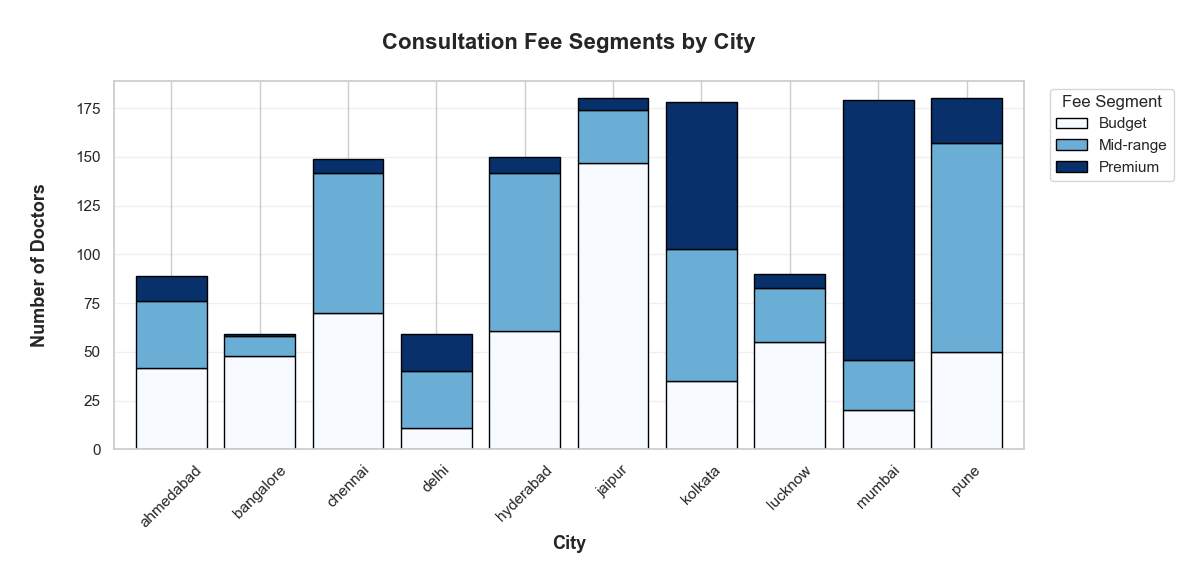

In [117]:
sns.set_theme(style="whitegrid")
ax = city_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Blues",
    edgecolor="black",
    width=0.8
)

plt.title("\nConsultation Fee Segments by City\n", fontsize=16, fontweight="bold")
plt.xlabel("City\n", fontsize=13, fontweight="bold")
plt.ylabel("\nNumber of Doctors\n", fontsize=13, fontweight="bold")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    title="Fee Segment",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**B) Segment Distribution by Specialization**

In [118]:
spec_segment = pd.crosstab(df["Specialization"], df["Fee_Segment"])
spec_segment

Fee_Segment,Budget,Mid-range,Premium
Specialization,,,
Ayurveda,4,3,0
Homoeopath,8,2,3
Sexologist,1,0,0
Anesthesiologist,3,0,3
Audiologist,0,1,0
Bariatric Surgeon,0,1,3
Cardiac Surgeon,0,2,3
Cardiologist,6,15,12
Cardiothoracic Surgeon,0,3,2


**Visualization : Consultation Fee segment by Specialization**

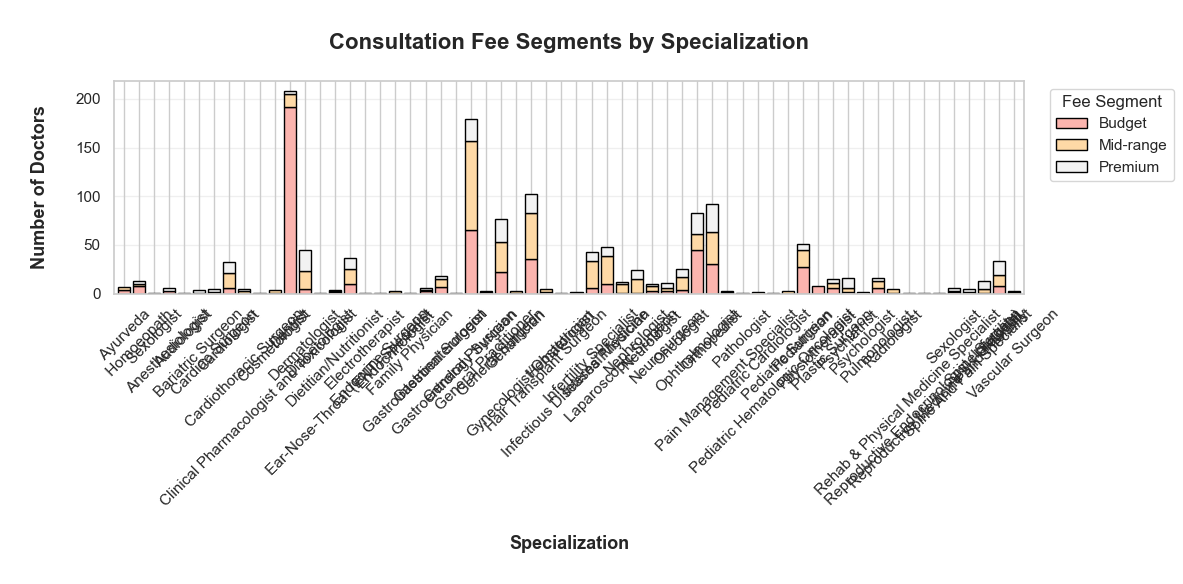

In [120]:
sns.set_theme(style="whitegrid")
ax = spec_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Pastel1",
    edgecolor="black",
    width=0.8
)

plt.title("\nConsultation Fee Segments by Specialization\n", fontsize=16, fontweight="bold")
plt.xlabel("\nSpecialization\n", fontsize=13, fontweight="bold")
plt.ylabel("\nNumber of Doctors\n", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    title="Fee Segment",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

This reveals which medical domains dominate premium healthcare.

In [121]:
# Premium Share by City (Advanced Insight)

premium_share_city = city_segment.div(city_segment.sum(axis=1), axis=0)
premium_share_city

Fee_Segment,Budget,Mid-range,Premium
City,,,
ahmedabad,0.471910,0.382022,0.146067
bangalore,0.813559,0.169492,0.016949
chennai,0.469799,0.483221,0.046980
delhi,0.186441,0.491525,0.322034
hyderabad,0.406667,0.540000,0.053333
jaipur,0.816667,0.150000,0.033333
kolkata,0.196629,0.382022,0.421348
lucknow,0.611111,0.311111,0.077778
mumbai,0.111732,0.145251,0.743017


This shows the percentage of premium doctors in each city.

In [123]:
# Premium Share by Specialization

premium_share_spec = spec_segment.div(spec_segment.sum(axis=1), axis=0)
premium_share_spec

Fee_Segment,Budget,Mid-range,Premium
Specialization,,,
Ayurveda,0.571429,0.428571,0.000000
Homoeopath,0.615385,0.153846,0.230769
Sexologist,1.000000,0.000000,0.000000
Anesthesiologist,0.500000,0.000000,0.500000
Audiologist,0.000000,1.000000,0.000000
Bariatric Surgeon,0.000000,0.250000,0.750000
Cardiac Surgeon,0.000000,0.400000,0.600000
Cardiologist,0.181818,0.454545,0.363636
Cardiothoracic Surgeon,0.000000,0.600000,0.400000


This identifies which specialties dominate the premium segment.

### INSIGHTS: Market Segment Pricing Analysis
1. Insight-01 — Structured Price Segmentation
    The healthcare market follows a clear hierarchy. Out of the analyzed sample, the Budget segment is the largest with 539 doctors, followed by Mid-range (482) and Premium (292). This distribution indicates a healthy "base" of accessible providers, though the premium segment remains a significant exclusive tier.
2. Insight-02 — Mumbai & Kolkata: The Premium Strongholds
    The stacked bar chart reveals that the "Premium" segment is not evenly distributed across India.
    Mumbai is the most top-heavy market, with 133 premium doctors and very few budget options.
   Kolkata follows a similar trend with 75 premium providers.
In these cities, specialized and high-cost healthcare is the standard rather than the exception.
3. Insight-03 — Jaipur & Hyderabad: The Budget Havens
Conversely, emerging or Tier-2 cities provide much higher accessibility.
Jaipur stands out as the most accessible city, with 147 doctors falling into the Budget segment and almost no Premium representation.
Hyderabad and Chennai show a strong Mid-range presence, indicating a balanced market where costs are moderate and predictable.
4. Insight-04 — Specialization-Driven Pricing
Your specialization-wise stacked chart highlights that certain fields are "locked" into specific segments.
General Physicians and Gynecologists have the highest volume in the Budget and Mid-range segments, making primary care relatively accessible.
Surgical Specialties (like Cardiac and Neurosurgeons) show a much higher proportion of Premium and Mid-range slots, confirming that technical complexity directly drives the pricing tier.